# Tracks in 3He Detectors

We have been finding a range of odd pulse shapes in the the data from our LND 3He neutron detector processed through a CAEN pre-amp. In particular, while many pulses have a simple rise/exponential decay form others show two clear bumps and still others are so wide and flat as to have no discernable shape. We are trying to understand how these could arise.

We start from the idea that energy deposition follows the form
$$\dfrac{dE}{dx}=-k\dfrac{Z^{2}m}{E(x)}$$
where $Z$ is the charge of the particle losing energy, $m$ its mass, and $k$ a constant.

We can re-write this as the non-linear differential equation
$$E(x)\dfrac{dE}{dx}=-kmZ^{2}$$

Noting that
$$\dfrac{dE^{2}(x)}{dx}=2E(x)\dfrac{dE}{dx}$$
we can re-write this as
$$\dfrac{dE^{2}(x)}{dx}=-2kmZ^{2}$$
which has the solution
$$E^{2}(x)=-2kmZ^{2}x+C$$
or
$$E(x)=\sqrt{E_0^{2}-2kmZ^{2}x}$$
where $E_{0}$ is the initial energy of the charged particle.|

Thus, if we let the range of the particle be R then we know that
$$E(R)=\sqrt{E_0^{2}-2kmZ^{2}R}=0$$
so that
$$E_0^{2}-2kmZ^{2}R=0$$
or
$$2kmZ^{2}=\dfrac{E_0^{2}}{R}$$
allowing us re-write the energy as
$$E(x)=E_0\sqrt{1-\dfrac{x}{R}}$$

If we normalize then we can plot a universal energy curve

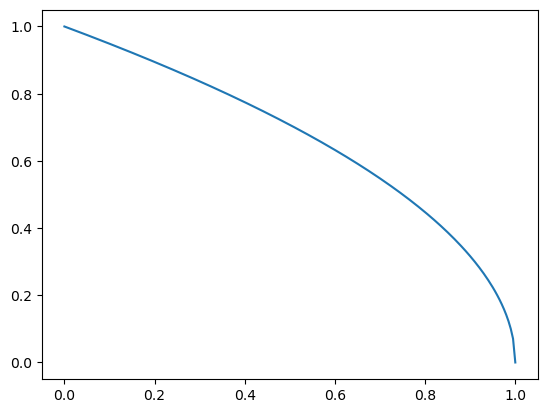

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0,1,num=201)
y = np.sqrt(1-x)
plt.plot(x, y)

From this we learn that 50% of all the charge is deposited in the last 1/4 of the track length.

## Neutron-induced decay of 3He

When a neutron is absorbed by an 3He nucleus the resulting 4He is unstable and decays into a proton and a triton releasing about 800 keV of total energy. Since, compared to the energy scale of the products, the original 3He was essentially at rest the decay products emerge back-to-back and with the energy split according to the mass ratio.
$$m_{1}v_{1}+m_{2}v_{2}=0\qquad{}\mathrm{and}\qquad{}m_{1}v_{1}^{2}+m_{2}v_{2}^{2}=2E_{tot}$$
The first gives us
$$v_{2}=-\dfrac{m_{1}v_{1}}{m_{2}}$$
which we susbtitute into the second to find
$$m_{1}v_{1}^{2}+m_{2}{\left( \dfrac{m_{1}v_{1}}{m_{2}}\right) }^{2}=m_{1}v_{1}^{2}+\left( \dfrac{m_{1}}{m_{2}}\right)m_{1}v_{1}^{2} =2E_{tot}$$
so that
$$E_{1}=\dfrac{1}{1+\left( \dfrac{m_{1}}{m_{2}}\right)}E_{tot}$$

This means that in our case with the proton ($m_1$) being 1/3 the mass of the triton ($m_2$) we get $E_1=\dfrac{3E_{tot}}{4}$ and $E_2=\dfrac{E_{tot}}{4}$ or about 600 keV for the proton and 200 keV for the triton so that the proton track is three times as long and deposits three times the charge or energy as the triton. Se we get a roughly linear track of charge with the largest concentration at the ends, something like this

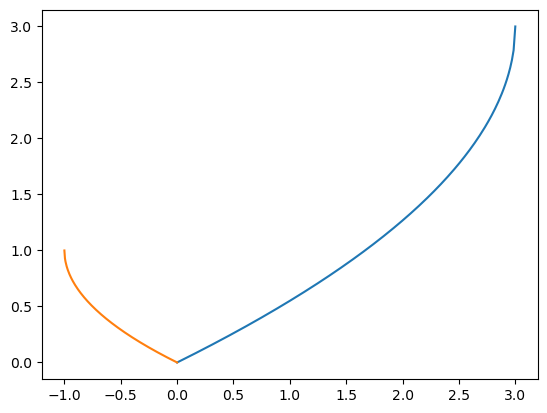

In [6]:
xp = np.linspace(0,3,num=201)
qp = 3 * (1-np.sqrt(1-xp/3))
qt = 1-np.sqrt(1-x)
plt.plot(xp, qp, -x, qt)

Now that is probably not fair because it is not the rate of deposition that is uniformly tripled but the total charge. Let's go back to the original form of the deposition equation
$$E(x)=\sqrt{E_0^{2}-2kmZ^{2}x}$$
Now the proton and triton have the same k value and the same charge but different masses and different starting energies so we have for the proton
$$E_p(x)=\sqrt{9E_{t0}^{2}-2kx}$$
and for the triton
$$E_t(x)=\sqrt{E_{t0}^{2}-6kx}$$
where $E_{t0}$ is the initial energy of the triton.
Scaling out $E_{t0}$ we get
$$E_p(x)=E_{t0}\sqrt{9-\dfrac{2kx}{E_{t0}^{2}}}$$
and
$$E_t(x)=\sqrt{1-\dfrac{6kx}{E_{t0}^{2}}}$$

This would say that the range of the proton is $9E_{t0}^2/2k$ while that of the triton is $E_{t0}^2/6k$ which is wrong because the ranges are proportional to the initial energies. Maybe not. From before
$$R=\dfrac{E_0^2}{2kmZ^2}$$
so the more massive triton should indeed have a range which is 1/27th that of the proton as it starts with less energy and loses energy faster. The problem is that this disagrees with the pulse shape Nico paper that says that the proton track is $3\times$ the length of the triton one.

## Restart

So all that was based on a mis-interpretation of the key first equation. What that equation should actually say is
$$\dfrac{\Delta{}E}{\Delta{}x}=-k\dfrac{Z^{2}m}{E_{in}}$$
where the $\Delta{}E$ is the total energy loss, $\Delta{}x$ the range of the particle, and $E_{in}$ the initial energy of the particle.

This is a statement about how the range depends on energy, mass, and charge and *not* a statement about the process of energy loss. We get a much better look at the process of energy loss by looking at curves of "$\dfrac{dE}{dx}$" as a function of energy.

![Insert](ProtonRange.png)

I *think* that this was measured by passing protons through some thickness of gas and measuring the energy loss, NOT by measuring the stopping range. In that case we can treat the value of $\dfrac{dE}{dx}$ as meaningful. We see that over a rather large range this value follows some negative power of E (straight line on a log-log plot) but flattens out at low energies. Note that we are interested in protons that start with 573 keV of energy and tritons that start with 191 keV.

Let's start by pulling a slope from the graph. At 1 MeV the proton is losing energy at a rate of 50 keV/cm and at 10 MeV that rate has fallen to 8 keV/cm so that the in one decade of energy the rate has fallen by a factor of 50/8 = 6.25 giving us a slope of 0.625 over most of the energy range and that becomes almost flat at about 200 keV/cm as the proton energy approaches 0. We will make only a small error if we take the rate
as always following the rule
$$\dfrac{dE}{dx}=-k{E^{-5/8}}$$
where we know that $k$ depends on $m$ and $Z$ so as to reproduce the original dependence.

This is now in a form that we can cast as a differential equation
$${E^{5/8}}{dE}=-k{dx}$$
which is integrable to give
$$\dfrac{8}{13}E^{13/8}=C-kx$$
or, using the boundary condition $E(0)=E_{in}^{13/8}$
$$E = (E_{in}^{13/8}-kx)^{8/13}$$
and k is given by $k = E_{in}^{13/8}/R$, where $R$ is the range. This can then be written in the general form
$$E = E_{in}\left(1-\dfrac{x}{R}\right)^{8/13}$$
We can plot this in terms of the fractional track length, $\xi=x/R$, to see the general shape

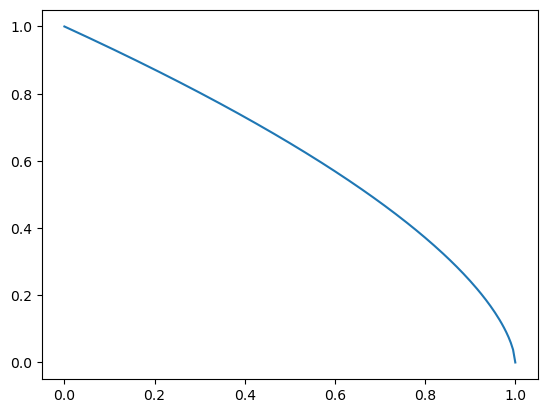

In [7]:
xi = np.linspace(0,1,num=201)
Erel = np.power(1-xi, 8/13)
plt.plot(xi, Erel)

We see that this is qualitively extremely similar to the previous version and still has a large fraction of the energy deposited in the tail of the track. In this case half the energy is lost in the last 33% of the track (rather than the last 1/4 in the previous case).

Now, we again assume that the charge deposited is proportional to the energy deposited with the constant being about $Q_{pair}=45$ eV/electron-ion pair for protons in He. Since tritons have the same charge I am going to guess that they have about the same constant. In that case, since the tritons start with 1/3 the energy of the protons they will generate about 1/3 of the total charge. 

Now to get the charge density at a particular point on the path I need to know the rate of change of the total charge at the point. I have the total charge as a function of position, given by
$$Q(x) = Q_{tot}\left(1-\dfrac{x}{R}\right)^{8/13}$$
where $Q_{tot} = E_{in}/Q_{pair}$ so the charge density is the derivative
$$\dfrac{dQ}{dx} = \dfrac{8Q_{tot}}{13}\left(1-\dfrac{x}{R}\right)^{-5/13}$$

So if I try to plot charge density for a proton-triton pair generated from a 4He decay I get something like this

Text(0.5, 0, 'Distance traveled (mm)')

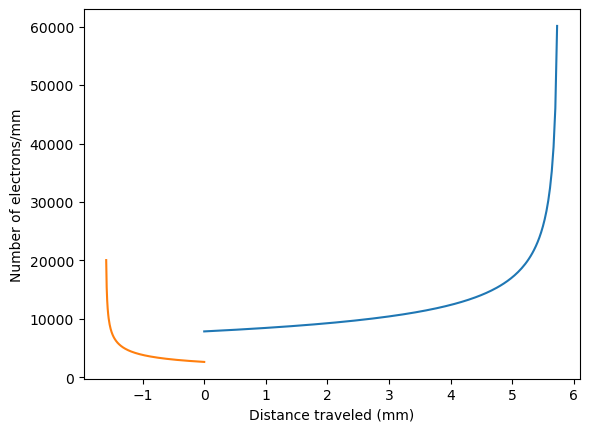

In [8]:
xi = np.linspace(0,1,num=201)
Ep = 573_000
Et = 191_000
Rp = 5.76
Rt = 1.6
Qpair = 45
Qp = 8 * Ep * np.power(1-xi[:-1], -5/13)/(13*Qpair)
Qt = 8 * Et * np.power(1-xi[:-1], -5/13)/(13*Qpair)

plt.plot(xi[:-1] * Rp, Qp, -xi[:-1] * Rt, Qt)
plt.ylabel('Number of electrons/mm')
plt.xlabel('Distance traveled (mm)')

Well, that looks like two tracks that are very strongly concentrated towards the ends. You can see how those might produce two peaks if the track is oriented roughly perpendicular to the electric field. Note that either peak could come first!

## Timing

How long does it take to make a track? Since we know the energy as a function of distance we can find the velocity as a function of distance.
$$\dfrac{1}{2}m\cdot{}v^{2} = E_{in}\left(1-\dfrac{x}{R}\right)^{8/13}$$
so
$$v(x)=\dfrac{dx}{dt}=\sqrt{\dfrac{2E_{in}}{m}\left(1-\dfrac{x}{R}\right)^{8/13}}=\sqrt{\dfrac{2E_{in}}{m}}\left(1-\dfrac{x}{R}\right)^{4/13}$$
or
$$\dfrac{dx}{\left(1-\dfrac{x}{R}\right)^{4/13}}=\sqrt{\dfrac{2E_{in}}{m}}{dt}$$
If I write $u=1-x/R$ so $du=-dx/R$ and $dx=-Rdu$ then I get
$$\dfrac{-Rdu}{u^{4/13}}=-Ru^{-4/13}du=\sqrt{\dfrac{2E_{in}}{m}}{dt}$$
Once again we can integrate to find
$$-13R\dfrac{u^{9/13}}{9}+C=\sqrt{\dfrac{2E_{in}}{m}}t$$
At $t=0$ we know $x=0$ giving $u=1$ so that
$$-\dfrac{13R}{9}+C=0$$
or
$$C=\dfrac{13R}{9}$$
and we find
$$\dfrac{13R}{9}-13R\dfrac{u^{9/13}}{9}=\sqrt{\dfrac{2E_{in}}{m}}t$$
so that the end of the track, where $u=0$ comes at time $T$. where
$$\sqrt{\dfrac{2E_{in}}{m}}T=\dfrac{13R}{9}$$
or
$$T=\dfrac{13R}{9}\sqrt{\dfrac{m}{2E_{in}}}$$

So for a proton, mass 938 MeV/c^2, KE = 573 keV, range 5.76 mm we get 
$$\dfrac{m}{2E_{in}}=\dfrac{1876\times{}10^{6}}{573\times{}10^{3}c^{2}}=\dfrac{1,876,000}{c^{2}}$$
or
$$\sqrt{\dfrac{m}{2E_{in}}}=\dfrac{1369.7}{c}=4.6\mu{}s/m$$
so that the formation time for the track is
$$T=\dfrac{13R}{9}\sqrt{\dfrac{m}{2E_{in}}}=\dfrac{13 * 5.76\times{}10^{-3}m}{9}\times{}4.6\mu{}s/m=38 ns$$
which is tiny compared to all the times that we measure.

## Gas Amplification

Once an electron has been produced by a primary ionization event (stealing about 45 eV from the energy of the incident ion) it starts to drift under the influence of the external electric field applied by the acceleration potential (~1400 V in our case). As it travels it gains kinetic energy some of which is lost to the surrounding gas but some of which goes to increase the chance of a further inelastic collision producing an additional electron. This process goes on underneath the overall drift velocity

## Drift Velocity

The electrons so produced start from rest and are accelerated by an electric field. However, the high density of gas (10 atm. of 3He) means that they travel only 1 mean free path before colliding with an He and having their velocity randomised. This keeps happening and so, on average, the electrons acquire a drift velocity equal to half the terminal velocity at the collision. So if we have an electric field $\mathscr{E}$ then a particle of mass $m$ and charge $q$ experiences an acceleration
$$a = \dfrac{q\mathscr{E}}{m}$$
and so if the particle starts with velocity $v_i$ and travels a distance $s$ then it will reach final velocity $v_f$ given by
$$v_{f}^{2}-v_{i}^{2}=2s\dfrac{q\mathscr{E}}{m}.$$
Immediately after a collision, our electrons start with average drift velocity 0. This is because although they have large individual velocities their directions are entirely random and so average to zero. However, the additional velocity gained from the electric field is coherent across all the electrons and so does contribute to the drift velocity. Since the electrons are in free flight between collisions they experience constant acceleration conditions and so the average drift velocity is simply one half of the final value,
$$v_{f}^{2} = 2s\dfrac{q\mathscr{E}}{m}$$
or
$$v_{d} = \sqrt{2s\dfrac{q\mathscr{E}}{m}}$$
In the gas, the average distance traveled between collisions is the mean free path. For particles traveling through an ideal gas at velocities which are high compared to that of the gas, the mean free path $\ell$ is given by
$$\ell=\dfrac{\mu}{P}\sqrt{\dfrac{\pi{}k_{B}T}{m_g}}$$
where $\mu$ is the dynamic viscosity, $P$ the pressure, $T$ the temperature, and $m_g$ the molecular mass. $k_{B}$ is Boltzmann's constant.

Helium has $\mu=19.85 \mu{}Pa\cdot{}s$ and molecular mass $m_{g}=5\times{}10^{-27} kg$ so that at the 10 atm pressure in our detector, $P=1.01 MPa$, and room temperature, $T=298 K$ we have
$$\ell=\dfrac{19.85\times{}10^{-6} Pa}{1.01\times{}10^{6}}\sqrt{\dfrac{\pi{}k_{B}T}{m_g}}$$

In [9]:
mu = 19.85E-6
P = 1.01E6
T=298
mg=5.0E-27
kB=1.38E-23
ell = mu * np.sqrt(np.pi * kB * T / mg) / P
print(ell)

3.15919727944518e-08


A 3He detector is a tube with inner radius $R2$ and with a central wire of radius $R1$. We apply a potential $V_0$ across the system which, over the central region, we can treat as a pair of concentric cylinders so that the potential is proportional to 1/r, the distance from the axis to the measurment point. So we can write the potential at r, $V(r)$ as $V(r)=A+B/r$ and apply the boundary conditions  $V(R1)=0$ and $V(R1)=V_0$ to find first
$$0=A+B/R2\rightarrow{}B=-A\cdot{}R2$$
and second
$$V_{0}=A+B/R1=A(1-R2/R1)\rightarrow{}A=\dfrac{R1V_{0}}{R1-R2}=\dfrac{-R1V_{0}}{R2-R1}$$
so that
$$V(r)=\dfrac{-R1V_{0}}{R2-R1}\left(1-\dfrac{R2}{r}\right)$$
The electric field is then the gradient of the potential, 
$$\mathscr{E}=\dfrac{dV}{dR}=\dfrac{R1V_{0}}{R2-R1}\left(\dfrac{R2}{r^2}\right)\simeq\dfrac{-R1V_{0}}{r^2}$$

With that we can find the range of drift velocities
$$v_{d} = \sqrt{2\ell\dfrac{q\mathscr{E}}{m}}=\sqrt{2\ell\dfrac{q}{m}}\sqrt{\mathscr{E}}$$


Our detector has inner radius, $R2=12.7$ mm but the manufacturer does not specify the radius of the central wire. However, they do tell us that the detector has an active length of 119 mm and a capacitance of 4 pF so that we can use the cylindrical capacitor formula to estimate the wire radius, $R1$ since a cylindrical capacitor of length $L$ has capacitance
$$C=\dfrac{2\pi{}\epsilon_{0}L}{\log_{10}(R2/R1)}$$
A little trial and error finds that for $L=0.0119$ m and $R1=0.2$ mm we get $C=3.6$ pF, very close to the data sheet value of 4 pF. Given that I will proceed using wire radius $R1=0.2$ mm.

In operation, we apply $V_{0}=1400$ V across the system so the electric field becomes, 
$$\mathscr{E}\simeq\dfrac{-R1V_{0}}{r^2}$$

which varies between $V_0/R1=1400/2\times{}10^{-4}=7\times10^6\;V/m$ down to $V_0/@=1400/(1.2\times{}10^{-2})=1.2\times10^5\;V/m$

With that we can find the range of drift velocities according to our simple theory in which
$$v_{d} = \sqrt{2\ell\dfrac{q}{m}}\sqrt{\mathscr{E}}$$
The prefactor is now computable

In [10]:
pre = np.sqrt(2 * ell * 1.66E-19 / 9.11E-31)
print(pre)

107.29963057726509


so that velocities range from vmin to vmax as given below in m/s.

In [11]:
vmin = pre * np.sqrt(1.2E5)
vmax = pre * np.sqrt(7E6)
print(vmin, vmax)

37169.68235863884 283888.13827654533


At those velocities the drift times will range up to a max of 1.2 cm / vmin

In [12]:
tmax = 0.012 / vmin
print('Max drift time = ',tmax, 's =',  1E6 * tmax, ' µs')

Max drift time =  3.2284375971297487e-07 s = 0.32284375971297485  µs


So we get drift times pretty much from 0 up to this maximum value. It is worth noting that the drift velocities only span a factor of 8 in range so that the variation of drift velocity with position is not a large effect.

This then also sets the expected longest time between the two pulses of a signal that shows the double pulse shape. Unfortunately, this is about 1/10 th of what we observe in practice.

### Drift Velocity Revisited

It appears that the simple theory of drift velocity outlined above gets the rough order of magnitude right but misses a lot of the fine points. A 1984 review article from CERN (CERN 84-08, saved locally as 15073101.pdf) gives an overview and includes a graph showing the drift velocity for electrons in He gas as a function of $\mathscr{E}/P$, the ratio of the field to the pressure.

![Insert](HeDriftVel.png)

Although rather hard to read this allows us to convert a range of $\mathscr{E}/P$ values to a range of drift speeds. We are interested in a pressure of 10 atm corresponding to 7,600 torr and electric fields that range from $7\times{}10^{4}$ V/cm down to $1.2\times{}10^{3}$ V/cm giving us a range of values for the ratio of between 0.16 V/cm/torr and 9.2 V/cm/torr.

Over the lower region of the electric field, which occupies most of the volume of the detector tube, we see a roughly straight line on the above log-log plot. In 1 horizontal decade there is a vertical rise of about log(8/3)=0.43 so that we get a velocity $w\propto\mathscr{E}^{0.43}$ that rises just a little more slowly than the $\sqrt{\mathscr{E}} = \mathscr{E}^{0.5}$ dependence assumed in our simple theory. As the electric field rises above about 1 V/cm/torr the slope starts to increase significantly as we switch from a rought $w\propto\sqrt{\mathscr{E}}$ towards something like $w\propto\mathscr{E}$, helping to account for the wider range of velocities seen in the data compared to that in our simple theory.

Careful perusal of the diagram (using magnification) gives us a range of velocities between $w_{min}=3\times{}10^{5}$ cm/s or 3,000 m/s and somewhere near $w_{max}=8\times{}10^{6}$ cm/s = $8\times{}10^{4}$ m/s. So the new minimum is about 1/20 of the old one and the max. time between pulses from a single track rises to several µs. As noted above, the new maximum is closer to the old vlaue at about 1/3 our simple value, as the field comes to have a larger effect on the drift velocity.

### Garfield++

A more sophisticated solution apparently exists in the form of a program call MagBoltz that can generate such curves for any gas at any pressure over any range of electric field strength. It, in turn, is part of a larger "Garfield++" package that appears to be a Monte-Carlo from CERN to do *exactly* what we want, calculate traces from gas counters. I fear that the best path forward is to install Garfield++ and learn to use it.

## Signal processing

OK, so we have a charge per unit length and if we throw in some angles and a drift velocity we should be able to convert these into a current arriving on the surface of the collector wire. There are a rather large number of possible variables here so it will not be easy to explore the space. I think that we will need some code. NOTE that even though this is going to be only a shadow of what Garfield++ claims to be able to do, it will be a valuable tool to build understanding in a simplified system.

Let's start by generating a point within the active volume. At least to start with I will make this a 2cm long tube with a radius of 12.7 mm. So we throw points in a 26 mm cube and then constrain to the active volume.

Create a class to represent a cylindrical detector described by a radius and length. Do minimal checking that these are sensible.

Give it a method to generate a point within the space and another to check that a point is within the space (this will be useful for bounds checking later).

In [14]:
import Track

class Point3D:
    def __init__(self, x=0.0, y=0.0, z=0.0):
        if x > -100.0 and x < 100.0:
            self.x = x
        else:
            raise ValueError('x out of range +/-100 or not a number')
        if y > -100.0 and y < 100.0:
            self.y = y
        else:
            raise ValueError('y out of range +/-100 or not a number')
        if z > -100.0 and z < 100.0:
            self.z = z
        else:
            raise ValueError('z out of range +/-100 or not a number')

    def radius(self):
        return np.sqrt(self.x * self.x + self.y * self.y)
        
    def from_spherical(self, r, theta, phi):
        if r < 0.0 or r > 100.0:
            raise ValueError('radius out of range 0-100 or not a number')
        if theta >= -np.pi and theta <= np.pi:
            self.z = r * np.cos(theta)
        else:
            raise ValueError('theta out of range +/-pi or not a number', theta)
        if phi >= -2*np.pi and phi <= 2*np.pi:
            self.x = r * np.sin(theta) * np.cos(phi)
            self.y = r * np.sin(theta) * np.sin(phi)
        else:
            raise ValueError('phi out of range +/-2pi or not a number', phi)
        return self

class Direction:
    def __init__(self, theta:float, phi:float):
        self.theta = float(theta)
        self.phi = float(phi)

def point_from_spherical(r, theta, phi):
    p = Point3D()
    p.from_spherical(r, theta, phi)
    return(p)

def point_from_direction(r, d:Direction):
    if not isinstance(d, Direction):
        raise ValueError('In point_from_direction argument must be a Direction.')
    p = Point3D()
    p.from_spherical(r, d.theta, d.phi)
    return(p)

# detector is a cylinder with its axis along the z direction and its base at z=0
class detector:
    def __init__(self, radius, length):
        if radius > 0 and radius < 0.1:
            self.radius = radius
        else:
            raise ValueError('Radius out of range 0-0.1 or not a number')
        if length > 0 and length < 0.1:
            self.length = length
        else:
            raise ValueError('length out of range 0-0.1 or not a number')
        self.zbound = 1.01 * self.length
        self.rbound = 1.01 * self.radius

    def contains(self, p:Point3D):
        if not isinstance(p, Point3D):
            raise ValueError('argument to is_inside must be of class point3D')
        if p.radius() > self.radius:
            return False
        if p.z < 0 or p.z > self.length:
            return False
        return True

    def new_point(self):
        while True:
            p = Point3D(random.uniform(-self.rbound, self.rbound),
                        random.uniform(-self.rbound, self.rbound),
                        random.uniform(0.0, self.zbound))
            if self.contains(p):
                return p

    def new_direction(self):
        while True:
            p = Point3D(random.uniform(-1.0, 1.0),
                        random.uniform(-1.0, 1.0),
                        random.uniform(-1.0, 1.0))
            if p.radius() <= 1.0:
                break
        phi = np.arctan2(p.y, p.x)
        theta = np.arctan2(p.radius(), p.z)
        return Direction(theta, phi)


This was checked by constructing and plotting 1000 points and the result was a cylindrical drum of points as expected.

![Insert](Points.png)

Right, now we can generate decay locations we need to generate and orientation for the track. We do this by generating a point in a centro-symmetric cube and taking the angles locating the point relative to the center. The test this time is to plot the points at unit radius and see that we get a uniformly covered sphere.

![Insert](Directions.png)

Again, we see exactly what we want to see.

Now we want to generate a point and add a direction then use that to generate two arrays of points holding the starting coordinates of the charges deposited by the ions. This gets a lot more specific so we are going to need to add a fair amount to our Detector class as well as adding some more support functions.

This has become too long to include in open cells but here is the code to generate the position part of a track

In [15]:
import Track

and then here is the result of generating a couple of tracks and plotting them.

![Insert](Track2.png)

Exactly as we hope, in each case we get two co-linear partial tracks that travel in opposite directions from the starting point and the proton part (in red) is about three times as long as the triton part (shown in blue).